# 0. Importando bibliotecas

In [60]:
pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tratamento

In [62]:
path_df_balanco_dia ="dataset_principal/balanco_servico_dia.csv"

df_balanco_dia = pd.read_csv(path_df_balanco_dia)

df_balanco_dia.head()

,data,servico,consorcio,km_apurada,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo,versao,datetime_ultima_atualizacao,id_execucao_dbt
0,2024-02-07,SN483,Internorte,526.046,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
1,2024-02-07,313,Internorte,2839.089,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
2,2024-02-07,385,Internorte,119.790,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
3,2024-02-07,920,Internorte,3377.366,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e
4,2024-02-07,249,Internorte,5411.151,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161,933971ef4769872f2b34a01c0fa8ae22488bdb85,2025-07-15 21:03:58.678701,9b1a0f21-cffb-42cf-ad0c-edf953ee336e


In [63]:
df_balanco_dia_tratado = df_balanco_dia.drop(columns=['km_apurada','versao','datetime_ultima_atualizacao','id_execucao_dbt'])
df_balanco_dia_tratado.head()

,data,servico,consorcio,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-02-07,SN483,Internorte,4697.59078,2572.36494,2125.22584,2125.22584,1005.89,1005.89,0.0,-1566.47494
1,2024-02-07,313,Internorte,25353.06477,13883.14521,11469.91956,11469.91956,17034.77,17034.77,0.0,3151.62479
2,2024-02-07,385,Internorte,1069.72470,585.77310,483.95160,483.95160,998.68,998.68,0.0,412.90690
3,2024-02-07,920,Internorte,30159.87838,16515.31974,13644.55864,13644.55864,24611.48,24611.48,0.0,8096.16026
4,2024-02-07,249,Internorte,48321.57843,26460.52839,21861.05004,21861.05004,53311.40,53311.40,0.0,26850.87161


In [64]:
path_df_servico_historico = "dataset_principal/sumario_servico_dia_historico.csv"

df_servico_historico = pd.read_csv(path_df_servico_historico)

df_servico_historico.head()

,data,tipo_dia,consorcio,servico,vista,viagens,km_apurada,km_planejada,perc_km_planejada,valor_subsidio_pago,valor_penalidade,datetime_ultima_atualizacao
0,2024-04-06,Sabado,Santa Cruz,383,Realengo - Praça da República,154,5154.242,6056.38,85.10,14980.27260,0.0,2025-09-22 12:32:31.291432
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba - Campo Grande,14,438.038,377.51,116.03,1769.67352,0.0,2025-09-22 12:32:31.291432
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy - Terminal Mato Alto,72,1738.368,1786.66,97.30,7023.00672,0.0,2025-09-22 12:32:31.291432
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto - Santa Cruz,17,297.490,279.71,106.36,990.32740,0.0,2025-09-22 12:32:31.291432
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo - Terminal Campo Grande,38,265.620,231.10,114.94,1073.10480,0.0,2025-09-22 12:32:31.291432


In [65]:
df_servico_historico[['bairro_inicio', 'bairro_fim']] = df_servico_historico['vista'].str.split('-', expand=True)
df_servico_historico_tratado = df_servico_historico.drop(columns=['datetime_ultima_atualizacao','valor_subsidio_pago','vista'])


In [66]:
df_final = df_servico_historico_tratado.merge(df_balanco_dia_tratado, on=['servico', 'data','consorcio'], how='inner')

In [67]:
df_final.head()

,data,tipo_dia,consorcio,servico,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,bairro_inicio,bairro_fim,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,154,5154.242,6056.38,85.10,0.0,Realengo,Praça da República,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,14,438.038,377.51,116.03,0.0,Sepetiba,Campo Grande,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,72,1738.368,1786.66,97.30,0.0,Vila Kennedy,Terminal Mato Alto,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,17,297.490,279.71,106.36,0.0,Terminal Mato Alto,Santa Cruz,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,38,265.620,231.10,114.94,0.0,Cantagalo,Terminal Campo Grande,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [68]:
# Reorganizando as colunas para melhorar a leitura

col = df_final.pop('bairro_inicio')
df_final.insert(4, 'bairro_inicio', col)

col = df_final.pop('bairro_fim')
df_final.insert(5, 'bairro_fim', col)


In [69]:
df_final.head()

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
0,2024-04-06,Sabado,Santa Cruz,383,Realengo,Praça da República,154,5154.242,6056.38,85.10,0.0,46027.38106,25204.24338,20823.13768,5842.86508,39321.03260,24340.76,14980.27260,-863.48338
1,2024-04-06,Sabado,Santa Cruz,SN898,Sepetiba,Campo Grande,14,438.038,377.51,116.03,0.0,3911.67934,2142.00582,1769.67352,0.00000,2332.97352,563.30,1769.67352,-1578.70582
2,2024-04-06,Sabado,Santa Cruz,853,Vila Kennedy,Terminal Mato Alto,72,1738.368,1786.66,97.30,0.0,15523.62624,8500.61952,7023.00672,0.00000,13869.00672,6846.00,7023.00672,-1654.61952
3,2024-04-06,Sabado,Santa Cruz,SN885,Terminal Mato Alto,Santa Cruz,17,297.490,279.71,106.36,0.0,2656.58570,1454.72610,1201.85960,211.53220,1370.44740,380.12,990.32740,-1074.60610
4,2024-04-06,Sabado,Santa Cruz,845,Cantagalo,Terminal Campo Grande,38,265.620,231.10,114.94,0.0,2371.98660,1298.88180,1073.10480,0.00000,1488.15480,415.05,1073.10480,-883.83180


In [70]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 60143 entries, 0 to 60142
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   data                        60143 non-null  str    
 1   tipo_dia                    60143 non-null  str    
 2   consorcio                   60143 non-null  str    
 3   servico                     60143 non-null  str    
 4   bairro_inicio               60143 non-null  str    
 5   bairro_fim                  60143 non-null  str    
 6   viagens                     60143 non-null  int64  
 7   km_apurada                  60143 non-null  float64
 8   km_planejada                60143 non-null  float64
 9   perc_km_planejada           60143 non-null  float64
 10  valor_penalidade            60143 non-null  float64
 11  receita_total_esperada      59771 non-null  float64
 12  receita_tarifaria_esperada  60143 non-null  float64
 13  subsidio_esperado           59771 non-null

### 1.1 Tratamento de nulos

In [71]:
df_final[df_final.isnull().any(axis=1)]

,data,tipo_dia,consorcio,servico,bairro_inicio,bairro_fim,viagens,km_apurada,km_planejada,perc_km_planejada,valor_penalidade,receita_total_esperada,receita_tarifaria_esperada,subsidio_esperado,subsidio_glosado,receita_total_aferida,receita_tarifaria_aferida,valor_subsidio_pago,saldo
40777,2024-08-16,Dia Útil,Intersul,110,Terminal Gentileza,Jardim de Alah,210,3194.988,3679.61,86.83,0.0,NaN,15623.49132,NaN,NaN,NaN,22038.14,NaN,6414.64868
40778,2024-08-16,Dia Útil,Intersul,448,Furnas,São Conrado,34,437.954,463.72,94.44,0.0,NaN,2141.59506,NaN,NaN,NaN,1822.13,NaN,-319.46506
40779,2024-08-16,Dia Útil,Intersul,LECD96,Metrô Botafogo,Terminal Alvorada,262,6064.908,5833.80,103.96,0.0,NaN,29657.40012,NaN,NaN,NaN,45948.76,NaN,16291.35988
40780,2024-08-16,Dia Útil,Intersul,472,Triagem,Leme,138,3002.880,2828.80,106.15,0.0,NaN,14575.33938,NaN,NaN,NaN,15744.03,NaN,1168.69062
40781,2024-08-16,Dia Útil,Intersul,461,São Cristóvão,Ipanema,116,3080.032,3425.21,89.92,0.0,NaN,15061.35648,NaN,NaN,NaN,17873.47,NaN,2812.11352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41144,2024-08-16,Dia Útil,Santa Cruz,866,Terminal Campo Grande,Pedra de Guaratiba,56,2274.832,2274.83,100.00,0.0,NaN,11123.92848,NaN,NaN,NaN,10969.30,NaN,-154.62848
41145,2024-08-16,Dia Útil,Transcarioca,SN954,Terminal Taquara,Recreio dos Bandeirantes,9,194.127,173.08,112.16,0.0,NaN,949.28103,NaN,NaN,NaN,223.24,NaN,-726.04103
41146,2024-08-16,Dia Útil,Transcarioca,954,Terminal Taquara,Recreio dos Bandeirantes,209,4522.402,4413.64,102.46,0.0,NaN,21902.95059,NaN,NaN,NaN,32149.72,NaN,10246.76941
41147,2024-08-16,Dia Útil,Santa Cruz,SV866,Terminal Campo Grande,Terminal Pingo d'Água,63,1198.309,1216.67,98.49,0.0,NaN,5859.73101,NaN,NaN,NaN,6660.95,NaN,801.21899


In [78]:
df_final = df_final.dropna().reset_index(drop=True)

In [79]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 59771 entries, 0 to 59770
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   data                        59771 non-null  datetime64[us]
 1   tipo_dia                    59771 non-null  str           
 2   consorcio                   59771 non-null  str           
 3   servico                     59771 non-null  str           
 4   bairro_inicio               59771 non-null  str           
 5   bairro_fim                  59771 non-null  str           
 6   viagens                     59771 non-null  int64         
 7   km_apurada                  59771 non-null  float64       
 8   km_planejada                59771 non-null  float64       
 9   perc_km_planejada           59771 non-null  float64       
 10  valor_penalidade            59771 non-null  float64       
 11  receita_total_esperada      59771 non-null  float64       
 12  r

# 2. Análise gráfica dos dados

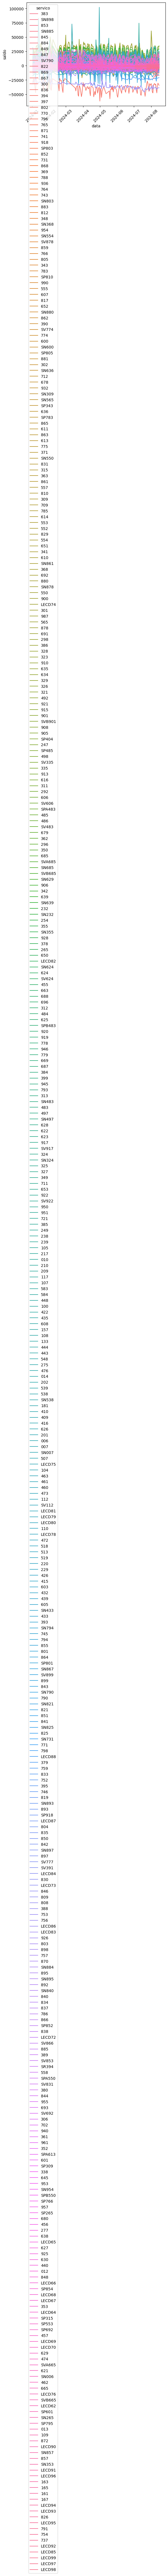

In [80]:
df_final['data'] = pd.to_datetime(df_final['data'])

sns.lineplot(data=df_final, x='data', y='saldo', hue='servico')

plt.xticks(rotation=45)
plt.show()

# 3. Pré-processamento

# 4. Analisando correlação entre as features

# 5. Treinamento do modelo

### 5.1 Dummy

### 5.2 Regressão linear

In [75]:
# TODO Resultados
# 1. Plotar um gráfico para series temporais comparando a relação de km_planejado e apurado, e talvez até um valor de receita com o balanco_servico_dias
# 2. Plotar um gráfico de subsidio_glosado e tentar verificiar anomalidades e fraudes em serviços (possíveis linhas fantasmas)
# 3. Plotar um gráfico com os serviços e consorcios que geram mais receita
# 4. Plotar um gráfico com os serviços com saldo negativo
# 5. Tentar achar uma relação entre linhas de ônibus onde o km_apurado é muito alto e possíveis problemas de passagem no csv trajeto alternativo
